In [11]:
pip install opencv-python scikit-image scikit-learn numpy scipy matplotlib

In [10]:
from google.colab import drive
drive.mount('/content/drive',  force_remount=True)

ZIP_PATH = "/content/drive/MyDrive/visao.zip"
!mkdir -p /content/dataset
!unzip -q -o "{ZIP_PATH}" -d /content/dataset

!find /content/dataset -maxdepth 3 -type d -name train

Mounted at /content/drive
/content/dataset/chest_xray/train


In [16]:
import glob
import os

import cv2
import joblib
import numpy as np
from imblearn.over_sampling import RandomOverSampler
from scipy.stats import kurtosis, skew
from skimage.feature import (graycomatrix, graycoprops, hog,
                             local_binary_pattern)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# DISCLAIMER: Foi utilizado como suporte o uso da IA generativa Claude 4.8, foi utilizado
# para correção de código, auxílio no uso de bibliotecas, para comentários no código e
# para a geração de código "burro" que faz processamento de dados.

# =============================================================================
# CONFIGURAÇÃO
# =============================================================================
BASE_DIR = "/content/dataset/chest_xray"
MODEL_PATH = "/content/drive/MyDrive/pneumonia_model.joblib"

CLASSES = ["NORMAL", "PNEUMONIA_BACTERIAL", "PNEUMONIA_VIRAL"]

IMG_SIZE = 256          # lado da imagem quadrada após o resize
GRID = 3                # a imagem é dividida em GRID x GRID células para textura
CLASSIFIER = "rf"       # "rf" (Random Forest) ou "svm"
USE_OVERSAMPLING = False  # balanceia as classes replicando exemplos minoritários

# Parâmetros de quantização usados na textura.
INTENSITY_HIST_BINS = 32  # bins do histograma para a entropia de intensidade
GLCM_LEVELS = 8           # níveis de cinza na matriz de co-ocorrência
GLCM_STEP = 256 // GLCM_LEVELS  # divisor que mapeia 0-255 em 0-(GLCM_LEVELS-1)


# =============================================================================
# CARREGAMENTO DOS CAMINHOS
# =============================================================================
def load_paths(split_dir: str):
    """Lista os arquivos de imagem de um split (train/test).

    Percorre uma pasta por classe e devolve, em paralelo:
      - paths:  lista de caminhos das imagens
      - labels: índice numérico da classe (0, 1, 2)
    """
    paths, labels = [], []
    for class_idx, class_name in enumerate(CLASSES):
        folder = os.path.join(split_dir, class_name)
        for ext in ("*.jpeg", "*.jpg", "*.png"):
            for path in glob.glob(os.path.join(folder, ext)):
                paths.append(path)
                labels.append(class_idx)

    return paths, np.array(labels)


# =============================================================================
# PRÉ-PROCESSAMENTO
# =============================================================================
# CLAHE = equalização de histograma adaptativa com limite de contraste.
# Realça estruturas locais (bordas de pulmão, opacidades) sem estourar o brilho.
_CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def preprocess(path: str) -> np.ndarray:
    """Lê a imagem em tons de cinza, redimensiona e aplica CLAHE."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Não foi possível ler a imagem: {path}")

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return _CLAHE.apply(img)


# =============================================================================
# EXTRAÇÃO DE FEATURES
# =============================================================================
def intensity_features(img: np.ndarray) -> list:
    """Estatísticas globais de intensidade da imagem.

    Descrevem o "brilho geral" e o formato da distribuição de pixels.
    """
    pixels = img.flatten().astype(np.float64)

    hist = cv2.calcHist([img], [0], None, [INTENSITY_HIST_BINS], [0, 256]).flatten()
    hist = hist / (hist.sum() + 1e-7)  # normaliza para virar distribuição de prob.
    entropy = -np.sum(hist * np.log2(hist + 1e-7))

    return [pixels.mean(), pixels.std(), skew(pixels), kurtosis(pixels), entropy]


def glcm_features(cell: np.ndarray) -> list:
    """Features de textura via matriz de co-ocorrência de níveis de cinza (GLCM).

    A célula é quantizada para GLCM_LEVELS níveis. A GLCM conta com que
    frequência pares de intensidades aparecem em 2 distâncias x 4 ângulos, e
    dela extraímos 6 propriedades estatísticas (contraste, homogeneidade etc.).
    """
    quantized = (cell // GLCM_STEP).astype(np.uint8)

    glcm = graycomatrix(
        quantized,
        distances=[1, 2],
        angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
        levels=GLCM_LEVELS,
        symmetric=True,
        normed=True,
    )

    feats = []
    for prop in ("contrast", "dissimilarity", "homogeneity",
                 "energy", "correlation", "ASM"):
        feats.extend(graycoprops(glcm, prop).flatten())
    return feats


def lbp_features(cell: np.ndarray, points: int = 8, radius: int = 1) -> list:
    """Histograma de Local Binary Patterns (LBP) da célula.

    O LBP codifica micro-texturas comparando cada pixel com seus vizinhos.
    O histograma normalizado resume a distribuição desses padrões locais.
    """
    lbp = local_binary_pattern(cell, points, radius, method="uniform")
    hist, _ = np.histogram(
        lbp, bins=points + 2, range=(0, points + 2), density=True
    )
    return hist.tolist()


def grid_texture_features(img: np.ndarray) -> list:
    """Textura local: divide a imagem em GRID x GRID células e concatena
    as features GLCM + LBP de cada uma.

    Fatiar em células preserva informação espacial: uma opacidade no lobo
    inferior direito afeta apenas as células daquela região.
    """
    feats = []
    for band in np.array_split(img, GRID, axis=0):        # faixas horizontais
        for cell in np.array_split(band, GRID, axis=1):   # colunas dentro da faixa
            feats.extend(glcm_features(cell))
            feats.extend(lbp_features(cell))
    return feats


def hog_features(img: np.ndarray) -> list:
    """Histogram of Oriented Gradients (HOG): descritor de forma/bordas.

    Captura a orientação dos gradientes em blocos da imagem
    """
    return hog(
        img,
        orientations=8,
        pixels_per_cell=(32, 32),
        cells_per_block=(2, 2),
        feature_vector=True,
    ).tolist()


def extract_features(img: np.ndarray) -> np.ndarray:
    """Monta o vetor de features final concatenando os três blocos.

    Ordem: intensidade (global) + textura (por célula) + HOG (forma).
    """
    vec = (
        intensity_features(img)
        + grid_texture_features(img)
        + hog_features(img)
    )
    return np.nan_to_num(np.array(vec, dtype=np.float64))


# =============================================================================
# CONSTRUÇÃO DO DATASET
# =============================================================================
def build_dataset(paths: list, labels: np.ndarray, tag: str):
    """Extrai a matriz de features X e devolve X e os rótulos.

    Percorre todas as imagens, pré-processa cada uma e concatena suas features.
    """
    print(f"[build] extraindo features de '{tag}' ({len(paths)} imagens)...")
    features = []
    for i, path in enumerate(paths, start=1):
        features.append(extract_features(preprocess(path)))
        if i % 200 == 0 or i == len(paths):
            print(f"  {i}/{len(paths)}")

    X = np.array(features)
    print(f"[build] pronto (tamanho do vetor = {X.shape[1]})")
    return X, labels


# =============================================================================
# CLASSIFICADOR
# =============================================================================
def make_classifier():
    """Cria o pipeline de classificação (padronização + modelo).

    StandardScaler normaliza as features (essencial para o SVM). O modelo é
    escolhido por CLASSIFIER; ambos usam class_weight balanceado.
    """
    if CLASSIFIER == "svm":
        model = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")
    else:
        model = RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
        )
    return make_pipeline(StandardScaler(), model)


def fit_classifier(X_train: np.ndarray, y_train: np.ndarray):
    """Treina o classificador, opcionalmente com oversampling das classes menores."""
    if USE_OVERSAMPLING:
        X_train, y_train = RandomOverSampler(random_state=42).fit_resample(
            X_train, y_train
        )
        print(f"  treino após oversampling -> {len(X_train)} imagens")

    clf = make_classifier()
    clf.fit(X_train, y_train)
    return clf


# =============================================================================
# TREINO / AVALIAÇÃO
# =============================================================================
def evaluate(clf, X_test: np.ndarray, y_test: np.ndarray, class_names: list):
    """Roda a predição no conjunto de teste e imprime as métricas.

    O Macro-F1 é destacado porque, com classes desbalanceadas, ele reflete
    melhor o desempenho por classe do que a acurácia bruta.
    """
    pred = clf.predict(X_test)

    print("\n=== Relatório de classificação ===")
    print(classification_report(y_test, pred, target_names=class_names, digits=3))

    print("=== Matriz de confusão (linhas=verdadeiro, colunas=predito) ===")
    print("rótulos:", class_names)
    print(confusion_matrix(y_test, pred))

    macro_f1 = f1_score(y_test, pred, average="macro")
    print(f"\nMacro-F1: {macro_f1:.3f} ")
    return pred


def main():
    """Orquestra o fluxo completo: carrega, extrai, treina, avalia e salva.

    Usa as pastas train/ e test/ já separadas no dataset.
    """
    train_dir = os.path.join(BASE_DIR, "train")
    test_dir = os.path.join(BASE_DIR, "test")

    train_paths, y_train = load_paths(train_dir)
    print("Contagem de treino:",
          {CLASSES[i]: int((y_train == i).sum()) for i in range(len(CLASSES))})
    X_train, y_train = build_dataset(train_paths, y_train, "train")

    test_paths, y_test = load_paths(test_dir)
    X_test, y_test = build_dataset(test_paths, y_test, "test")

    print(f"\nTreinando {CLASSIFIER.upper()}...")
    clf = fit_classifier(X_train, y_train)
    evaluate(clf, X_test, y_test, CLASSES)

    joblib.dump(
        {"model": clf, "classes": CLASSES, "img_size": IMG_SIZE, "grid": GRID},
        MODEL_PATH,
    )
    print(f"\nModelo salvo -> {MODEL_PATH}")
    return clf, X_test, y_test


def predict_one(image_path: str, model_path: str = MODEL_PATH) -> str:
    """Classifica uma única imagem usando um modelo já salvo."""
    bundle = joblib.load(model_path)
    features = extract_features(preprocess(image_path)).reshape(1, -1)
    predicted_idx = bundle["model"].predict(features)[0]
    return bundle["classes"][predicted_idx]


In [25]:
clf, Xte, yte = main()



Contagem de treino: {'NORMAL': 1349, 'PNEUMONIA_BACTERIAL': 2538, 'PNEUMONIA_VIRAL': 1345}
[build] extraindo features de 'train' (5232 imagens)...
  200/5232
  400/5232
  600/5232
  800/5232
  1000/5232
  1200/5232
  1400/5232
  1600/5232
  1800/5232
  2000/5232
  2200/5232
  2400/5232
  2600/5232
  2800/5232
  3000/5232
  3200/5232
  3400/5232
  3600/5232
  3800/5232
  4000/5232
  4200/5232
  4400/5232
  4600/5232
  4800/5232
  5000/5232
  5200/5232
  5232/5232
[build] pronto (tamanho do vetor = 2095)
[build] extraindo features de 'test' (624 imagens)...
  200/624
  400/624
  600/624
  624/624
[build] pronto (tamanho do vetor = 2095)

Treinando RF...

=== Relatório de classificação ===
                     precision    recall  f1-score   support

             NORMAL      0.941     0.406     0.567       234
PNEUMONIA_BACTERIAL      0.639     0.979     0.773       242
    PNEUMONIA_VIRAL      0.645     0.662     0.653       148

           accuracy                          0.689       6

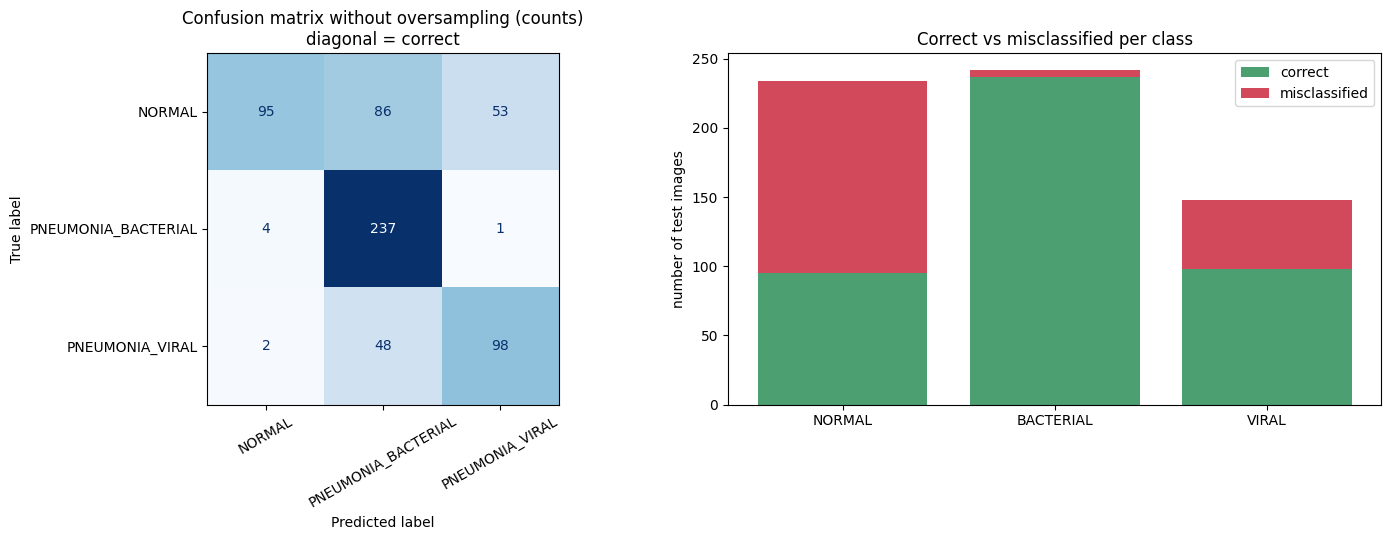

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = clf.predict(Xte)
cm = confusion_matrix(yte, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=ax1, cmap="Blues", colorbar=False, xticks_rotation=30)
if USE_OVERSAMPLING :
    ax1.set_title("Confusion matrix with oversampling (counts)\ndiagonal = correct")
else:
     ax1.set_title("Confusion matrix without oversampling (counts)\ndiagonal = correct")

labels_short = ["NORMAL", "BACTERIAL", "VIRAL"]
correct_per = [cm[i, i] for i in range(len(CLASSES))]
wrong_per   = [cm[i].sum() - cm[i, i] for i in range(len(CLASSES))]
x = np.arange(len(CLASSES))
ax2.bar(x, correct_per, label="correct", color="#4c9f70")
ax2.bar(x, wrong_per, bottom=correct_per, label="misclassified", color="#d1495b")
ax2.set_xticks(x); ax2.set_xticklabels(labels_short)
ax2.set_ylabel("number of test images")
ax2.set_title("Correct vs misclassified per class"); ax2.legend()
plt.tight_layout(); plt.show()